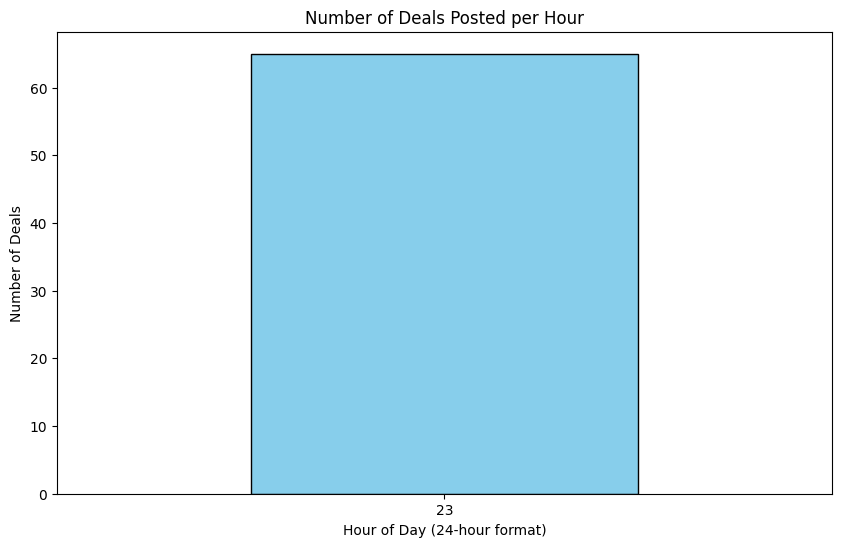

In [11]:
# Time Series Analysis

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("cleaned_ebay_deals.csv")

# Ensure numeric columns are numbers
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['original_price'] = pd.to_numeric(df['original_price'], errors='coerce')
df['discount_percentage'] = pd.to_numeric(df['discount_percentage'], errors='coerce')


df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')

df['hour'] = df['timestamp'].dt.hour
deals_per_hour = df.groupby('hour').size()


plt.figure(figsize=(10, 6))
deals_per_hour.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Number of Deals Posted per Hour')
plt.xlabel('Hour of Day (24-hour format)')
plt.ylabel('Number of Deals')
plt.xticks(rotation=0)
plt.show()

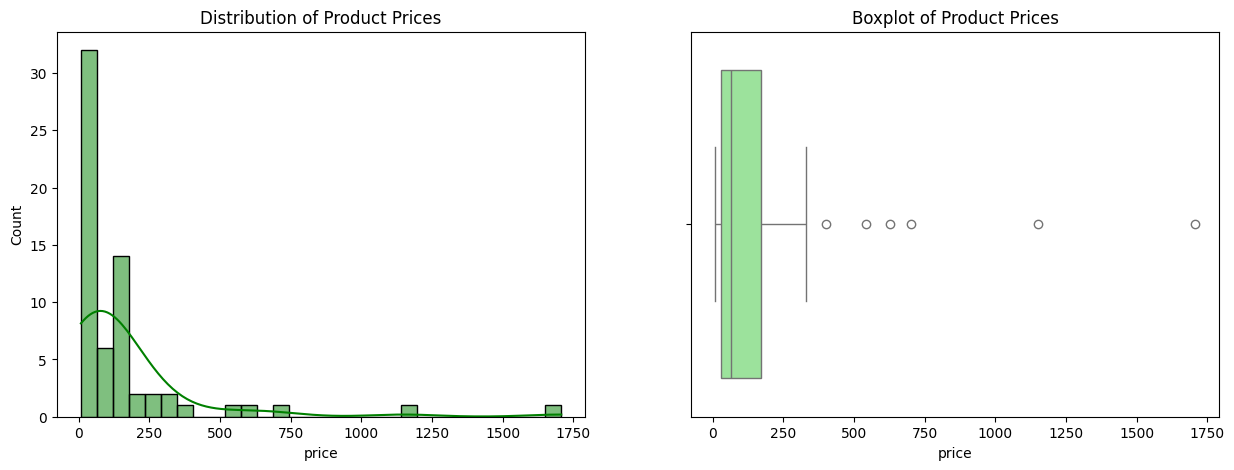

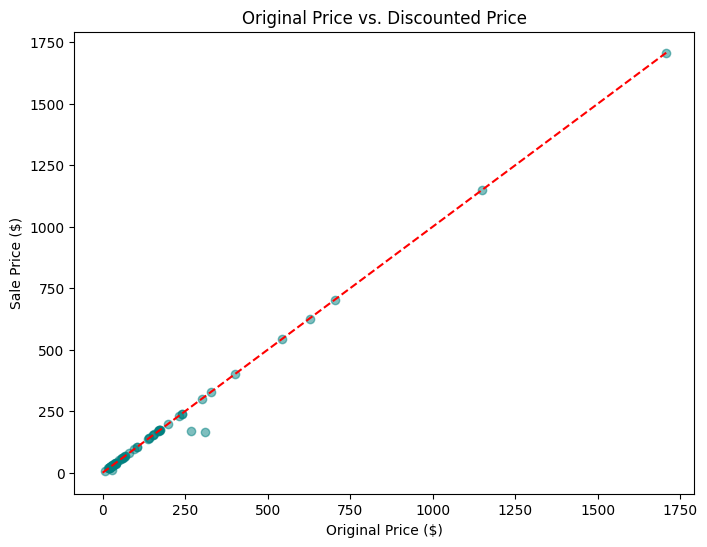

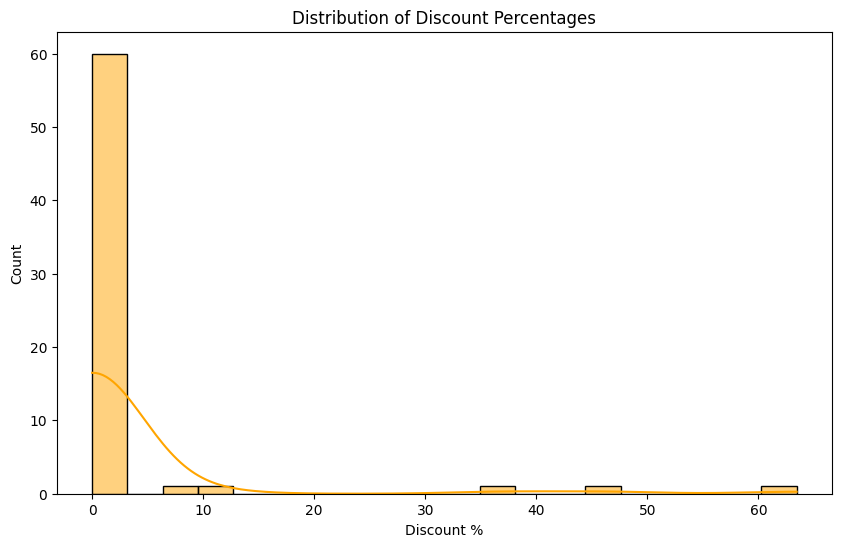

In [12]:
# Price and discount analysis

fig, ax = plt.subplots(1, 2, figsize=(15, 5))


sns.histplot(df['price'], bins=30, kde=True, ax=ax[0], color='green')
ax[0].set_title('Distribution of Product Prices')


sns.boxplot(x=df['price'], ax=ax[1], color='lightgreen')
ax[1].set_title('Boxplot of Product Prices')
plt.show()


plt.figure(figsize=(8, 6))
plt.scatter(df['original_price'], df['price'], alpha=0.5, color='teal')
plt.title('Original Price vs. Discounted Price')
plt.xlabel('Original Price ($)')
plt.ylabel('Sale Price ($)')
plt.plot([0, df['original_price'].max()], [0, df['original_price'].max()], 'r--') 
plt.show()


plt.figure(figsize=(10, 6))
sns.histplot(df['discount_percentage'], bins=20, kde=True, color='orange')
plt.title('Distribution of Discount Percentages')
plt.xlabel('Discount %')
plt.show()

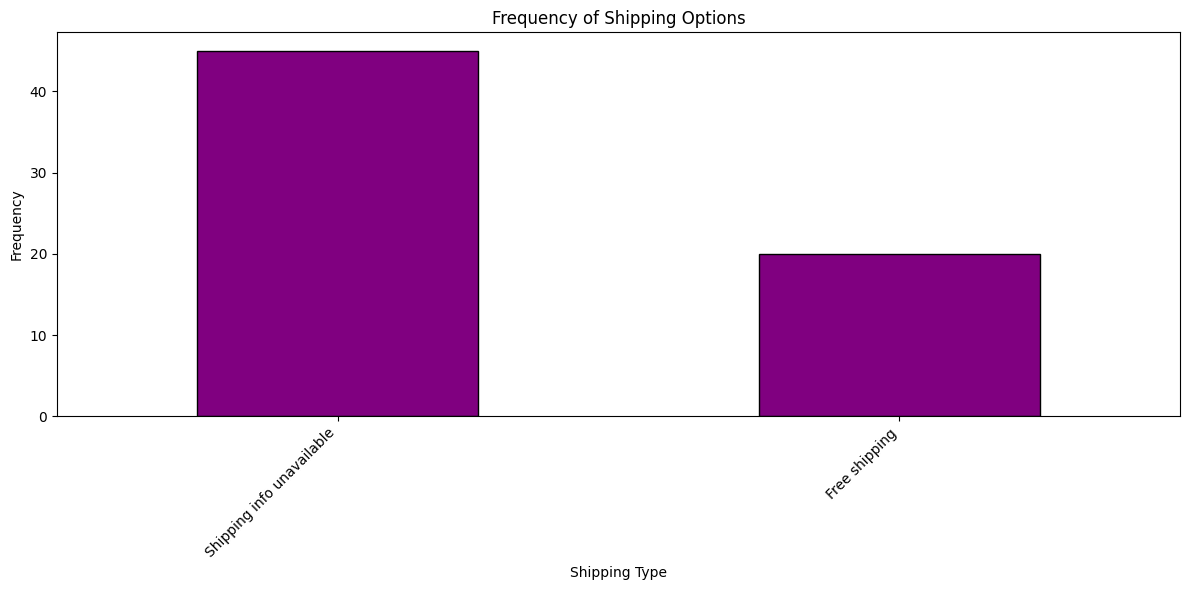

In [5]:
# Shipping information analysis

shipping_counts = df['shipping'].value_counts()

plt.figure(figsize=(12, 6))
shipping_counts.plot(kind='bar', color='purple', edgecolor='black')
plt.title('Frequency of Shipping Options')
plt.xlabel('Shipping Type')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\Rama_\AppData\Local\Temp\ipykernel_27260\3321241138.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=kw_series.index, y=kw_series.values, palette='viridis')


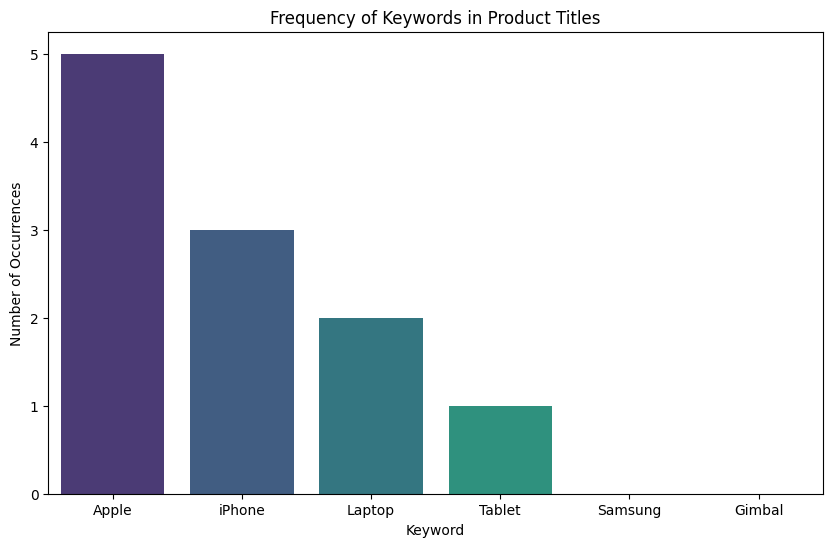

In [6]:
#  Text Analysis on Product Titles
keywords = ["Apple", "Samsung", "Laptop", "iPhone", "Tablet", "Gimbal"]
keyword_counts = {}

for kw in keywords:
    count = df['title'].str.contains(kw, case=False, na=False).sum()
    keyword_counts[kw] = count

kw_series = pd.Series(keyword_counts).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=kw_series.index, y=kw_series.values, palette='viridis')
plt.title('Frequency of Keywords in Product Titles')
plt.xlabel('Keyword')
plt.ylabel('Number of Occurrences')
plt.show()

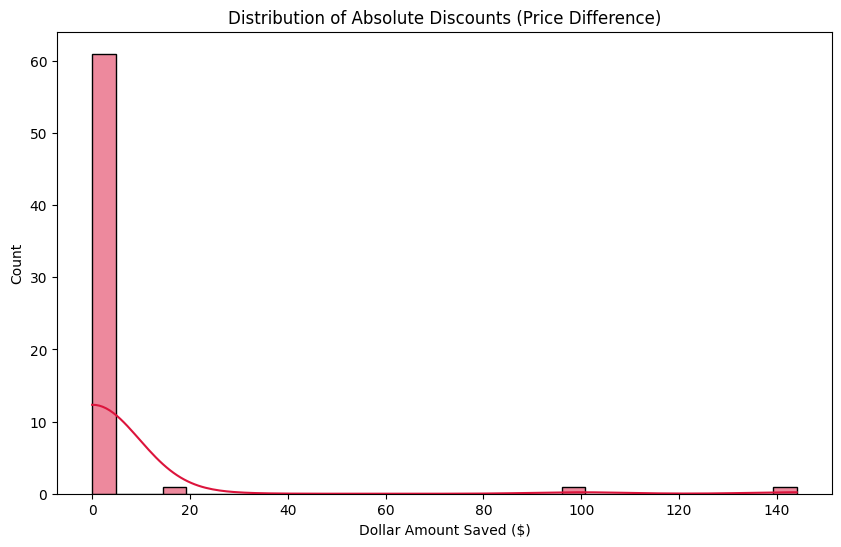

In [13]:
# Price Difference Analysis

df['price_difference'] = df['original_price'] - df['price']

plt.figure(figsize=(10, 6))
sns.histplot(df['price_difference'], bins=30, color='crimson', kde=True)
plt.title('Distribution of Absolute Discounts (Price Difference)')
plt.xlabel('Dollar Amount Saved ($)')
plt.show()

In [ ]:
#Top 5 Deals
top_deals = df.sort_values(by='discount_percentage', ascending=False).head(5)

print("Top 5 Deals with the Highest Discounts:")
print(top_deals[['title', 'price', 'original_price', 'discount_percentage']])



Top 5 Deals with the Highest Discounts:
                                                title   price  original_price  \
49  Married With Children ~ Complete 5th Fifth Sea...   10.95           29.95   
43  CANON RF-S10-18mm F4.5-6.3 IS STM Ultra Wide Z...  167.20          311.25   
27  12" Streaming Rear Camera Mirror with GPS Wifi...  169.47          269.00   
14  New Genuine MR22GA AKB76039907 For LG Magic Bl...   25.83           28.70   
1   Nokia 1209 - Midnight Blue (Unlocked) Cellular...   37.14           40.37   

    discount_percentage  
49                63.44  
43                46.28  
27                37.00  
14                10.00  
1                  8.00  
